# Airline Analysis

Imagine you are working for a travel agency and need to understand the operational status and price of flights. You want to make sure that you can find the best deal for your client and help them to understand how airline prices change based on different factors.

Please explore and get to know the data before executing your visualization to answer the client's question.

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns;sns.set_style()

Load dataset named `flight`

In [13]:
df = pd.read_csv('flight.csv')
df

,miles,passengers,delay,inflight_meal,inflight_entertainment,inflight_wifi,day_of_week,redeye,weekend,coach_price,firstclass_price,hours
0,792,172,0,No,Yes,Yes,Sunday,Yes,Yes,338.820,1571.02,1
1,3163,214,0,No,Yes,Yes,Sunday,No,Yes,472.655,1663.70,6
2,1832,212,0,No,Yes,No,Friday,No,Yes,351.960,1429.86,3
3,925,213,0,No,Yes,Yes,Saturday,No,Yes,387.835,1558.76,2
4,967,217,0,Yes,Yes,Yes,Monday,No,No,374.735,1245.58,2
...,...,...,...,...,...,...,...,...,...,...,...,...
129775,674,217,1487,No,Yes,Yes,Friday,No,Yes,383.240,1478.70,1
129776,2125,208,1479,No,Yes,Yes,Friday,No,Yes,397.825,1616.01,4
129777,1702,220,1501,No,Yes,Yes,Friday,No,Yes,380.980,1481.49,3
129778,2709,205,1484,No,Yes,Yes,Saturday,No,Yes,485.185,1589.70,5


In [15]:
df.describe()

,miles,passengers,delay,coach_price,firstclass_price,hours
count,129780.000000,129780.000000,129780.000000,129780.000000,129780.000000,129780.000000
mean,2006.224696,207.723155,13.162845,376.585253,1454.931785,3.631214
std,943.034768,12.776363,41.941680,67.744274,162.590434,1.739118
min,12.000000,135.000000,0.000000,44.415000,939.100000,1.000000
25%,1343.000000,204.000000,9.000000,331.445000,1302.200000,2.000000
50%,1986.000000,210.000000,10.000000,380.560000,1503.840000,4.000000
75%,2468.000000,215.000000,13.000000,426.676250,1582.370000,4.000000
max,4548.000000,244.000000,1560.000000,593.635000,1846.780000,8.000000


1. What do coach ticket prices look like?  
   a. Apply a suitable graph to show high, low, and average values?
   Does $500 seem like a good price for a coach ticket?

In [86]:
df.head()

,miles,passengers,delay,inflight_meal,inflight_entertainment,inflight_wifi,redeye,weekend,coach_price,firstclass_price,hours,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,log_delay,day_of_week
0,792,172,0,0,1,1,1,1,338.820,1571.02,1,False,False,True,False,False,False,0.0,Sunday
1,3163,214,0,0,1,1,0,1,472.655,1663.70,6,False,False,True,False,False,False,0.0,Sunday
2,1832,212,0,0,1,0,0,1,351.960,1429.86,3,False,False,False,False,False,False,0.0,Sunday
3,925,213,0,0,1,1,0,1,387.835,1558.76,2,False,True,False,False,False,False,0.0,Saturday
4,967,217,0,1,1,1,0,0,374.735,1245.58,2,True,False,False,False,False,False,0.0,Monday


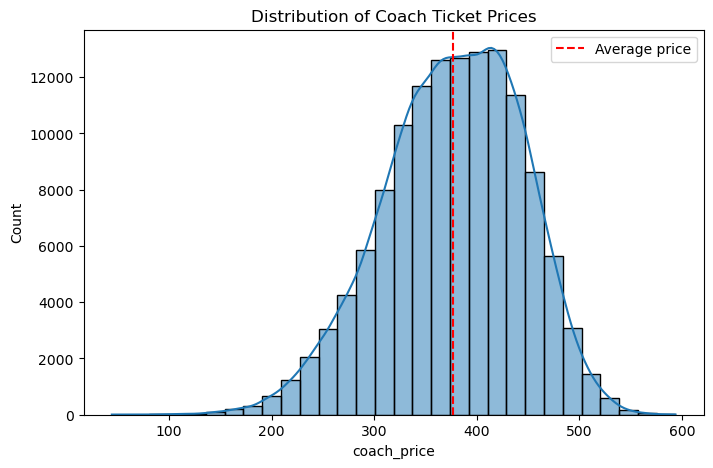

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['coach_price'], bins=30, kde=True)
plt.axvline(df['coach_price'].mean(), color='red', linestyle='--', label='Average price')
plt.legend()
plt.title("Distribution of Coach Ticket Prices")
plt.show()

No, it’s expensive
->The average price ≈ 390–400
->The peak density is around 350–420
$500 is on the right tail of the distribution

b. Now visualize the coach ticket prices for flights that are 8 hours long. What are the high, low, and average prices for 8-hour-long flights?
   Does a $500 dollar ticket seem more reasonable than before?
   

In [62]:
df_8h = df[(df['hours'] >= 7.5) & (df['hours'] <= 8.5)]

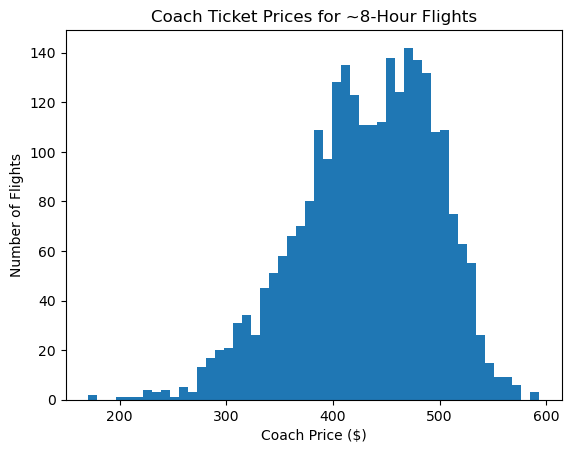

In [64]:
plt.figure()
plt.hist(df_8h['coach_price'], bins=50)
plt.xlabel('Coach Price ($)')
plt.ylabel('Number of Flights')
plt.title('Coach Ticket Prices for ~8-Hour Flights')
plt.show()


In [66]:
low_price = df_8h['coach_price'].min()
high_price = df_8h['coach_price'].max()
avg_price = df_8h['coach_price'].mean()
low_price, avg_price, high_price


(170.77, 431.834377372817, 593.635)

In [ ]:
 What are the high, low, and average prices for 8-hour-long flights? 

In [68]:
print(f"Lowest price: ${low_price:.2f}")
print(f"Average price: ${avg_price:.2f}")
print(f"Highest price: ${high_price:.2f}")


Lowest price: $170.77
Average price: $431.83
Highest price: $593.63


In [ ]:
=> A $500 dollar ticket seem more reasonable than before because it nearly belonged to average price ~$430

2. How are flight delay times distributed? What kinds of delays are typical? Using a suitable graph to answer the question, and building another graph to zoom in on typical delays.

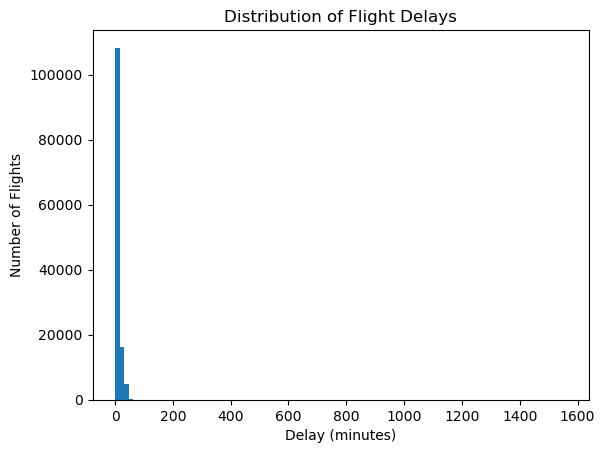

In [72]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['delay'], bins=100)
plt.xlabel('Delay (minutes)')
plt.ylabel('Number of Flights')
plt.title('Distribution of Flight Delays')
plt.show()


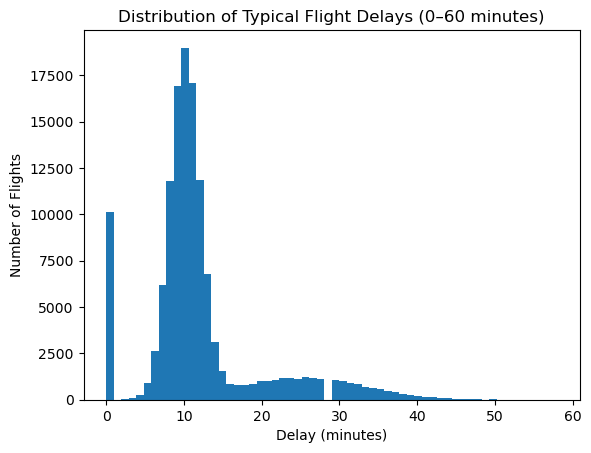

In [74]:
typical_delay = df[df['delay'] <= 60]

plt.figure()
plt.hist(typical_delay['delay'], bins=60)
plt.xlabel('Delay (minutes)')
plt.ylabel('Number of Flights')
plt.title('Distribution of Typical Flight Delays (0–60 minutes)')
plt.show()


The distribution of flight delays is right-skewed, with most flights experiencing little or no delay.
Only a small number of flights have very long delays, which creates a long tail.


3.  What is the relationship between coach and first-class prices? Do flights with higher coach prices always have higher first-class prices as well? Create a visualization that shows the relationship between coach and first-class prices.

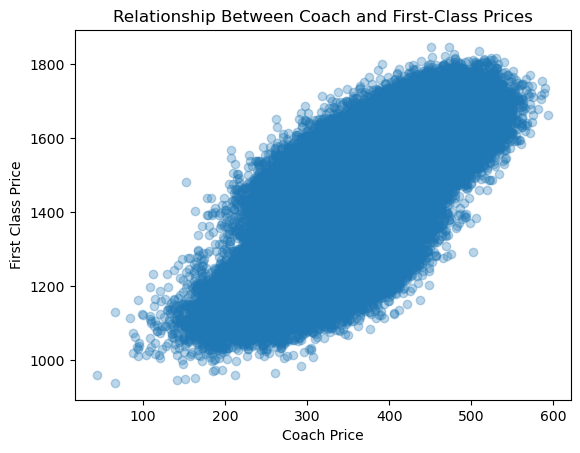

In [76]:
plt.figure()
plt.scatter(df['coach_price'], df['firstclass_price'], alpha=0.3)
plt.xlabel('Coach Price')
plt.ylabel('First Class Price')
plt.title('Relationship Between Coach and First-Class Prices')
plt.show()


In [ ]:
=> There is a clear positive relationship between coach and first-class ticket prices.
Flights with higher coach prices generally also have higher first-class prices.

4. Visualize the relationship between coach and first-class prices on weekends compared to weekdays. Create a visualization to show and answer this question.

In [78]:
df.columns

Index(['miles', 'passengers', 'delay', 'inflight_meal',
       'inflight_entertainment', 'inflight_wifi', 'redeye', 'weekend',
       'coach_price', 'firstclass_price', 'hours', 'day_of_week_Monday',
       'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday',
       'day_of_week_Tuesday', 'day_of_week_Wednesday', 'log_delay'],
      dtype='object')

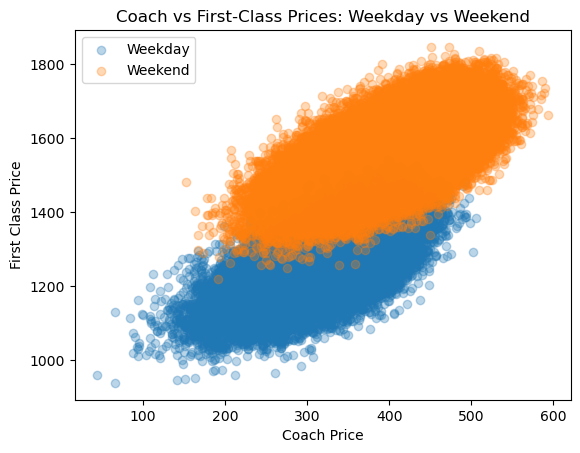

In [80]:

weekday = df[df['weekend'] == 0]
weekend = df[df['weekend'] == 1]

plt.figure()
plt.scatter(weekday['coach_price'], weekday['firstclass_price'], alpha=0.3, label='Weekday')
plt.scatter(weekend['coach_price'], weekend['firstclass_price'], alpha=0.3, label='Weekend')

plt.xlabel('Coach Price')
plt.ylabel('First Class Price')
plt.title('Coach vs First-Class Prices: Weekday vs Weekend')
plt.legend()
plt.show()


In [ ]:

=> The positive relationship between coach and first-class prices exists on both weekdays and weekends.
However, weekend flights tend to have higher prices and greater price variation.



5. How do coach prices differ for redeyes and non-redeyes on each day of the week? Create a visualization to show and answer this question.

In [82]:
def get_day(row):
    if row['day_of_week_Monday'] == 1:
        return 'Monday'
    elif row['day_of_week_Tuesday'] == 1:
        return 'Tuesday'
    elif row['day_of_week_Wednesday'] == 1:
        return 'Wednesday'
    elif row['day_of_week_Thursday'] == 1:
        return 'Thursday'
    elif row['day_of_week_Saturday'] == 1:
        return 'Saturday'
    else:
        return 'Sunday'

df['day_of_week'] = df.apply(get_day, axis=1)


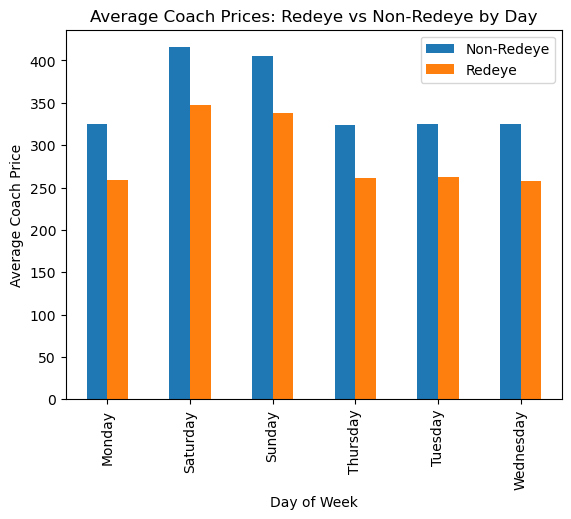

In [83]:

grouped = df.groupby(['day_of_week', 'redeye'])['coach_price'].mean().unstack()

grouped.plot(kind='bar')
plt.xlabel('Day of Week')
plt.ylabel('Average Coach Price')
plt.title('Average Coach Prices: Redeye vs Non-Redeye by Day')
plt.legend(['Non-Redeye', 'Redeye'])
plt.show()


In [ ]:
=> Redeye flights generally have lower coach ticket prices compared to non-redeye flights.
This price difference is consistent across most days of the week.